# Continuous Tillage Duration Distribution by Year
# Fig 1(c)


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch


LOW_TILL_BINS = ["1_4", "5_9", "10_14", "15_19", "20+"]
ALL_CONV_LABEL = "Conventional (all)"
NEVER_CONV_LABEL = "Conventional (never low-till)"

PLOT_STYLE = {
    ALL_CONV_LABEL: {"color": "#2f2f2f", "hatch": "///"},
    NEVER_CONV_LABEL: {"color": "#8c8c8c", "hatch": ""},
    "1_4": {"color": "#c7e9b4", "hatch": ""},
    "5_9": {"color": "#7fcdbb", "hatch": ""},
    "10_14": {"color": "#41b6c4", "hatch": ""},
    "15_19": {"color": "#1d91c0", "hatch": ""},
    "20+": {"color": "#225ea8", "hatch": ""},
}


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "tillage_duration" / "processed_smooth_1999_2023").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/tillage_duration/processed_smooth_1999_2023")


def duration_bin_from_streak(series: pd.Series) -> pd.Series:
    return pd.Series(
        pd.Categorical(
            pd.cut(
                series,
                bins=[0, 4, 9, 14, 19, float("inf")],
                labels=LOW_TILL_BINS,
                right=True,
            ),
            categories=LOW_TILL_BINS,
            ordered=True,
        ),
        index=series.index,
    )


def build_pivot(df: pd.DataFrame, category_col: str, category_order: list[str]) -> pd.DataFrame:
    counts = (
        df.groupby(["year", category_col], observed=False)
        .size()
        .rename("fields")
        .reset_index()
    )
    return (
        counts.pivot(index="year", columns=category_col, values="fields")
        .reindex(columns=category_order)
        .fillna(0)
        .astype(int)
    )

LEGEND_LABELS = {
        "1_4": "Low Till (1~4 years)",
        "5_9": "Low Till (5~9 years)",
        "10_14": "Low Till (10~14 years)",
        "15_19": "Low Till (15~19 years)",
        "20+": "Low Till (20+ years)",
        "Conventional (all)": "Conventional (all)",
        "Conventional (never low-till)": "High Till",
    }

def legend_handles(category_order: list[str]) -> list[Patch]:
    handles = []
    for label in category_order:
        style = PLOT_STYLE[label]
        handles.append(
            Patch(
                facecolor=style["color"],
                edgecolor="black",
                hatch=style["hatch"],
                label=LEGEND_LABELS.get(label, label),
            )
        )
    return handles


def plot_stacked(ax, table: pd.DataFrame, category_order: list[str], title: str, ylabel: str, as_share: bool = False) -> None:
    plot_table = table.copy()
    if as_share:
        plot_table = plot_table.div(plot_table.sum(axis=1), axis=0)

    years = plot_table.index.to_numpy()
    ax.set_xticks(np.arange(1999, 2024, 2))
    
    bottom = np.zeros(len(plot_table), dtype=float)

    for label in category_order:
        style = PLOT_STYLE[label]
        values = plot_table[label].to_numpy(dtype=float)
        ax.bar(
            years,
            values,
            bottom=bottom,
            width=0.82,
            color=style["color"],
            hatch=style["hatch"],
            edgecolor="black",
            linewidth=0.45,
        )
        bottom = bottom + values

    ax.set_title(title, fontsize=24)
    ax.set_ylabel(ylabel, fontsize=18)
    #ax.set_xlabel("Year")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(years.min() - 0.7, years.max() + 0.7)
    ax.tick_params(axis="x", rotation=0, labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

    if as_share:
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])

    

    ax.legend(
    handles=legend_handles(category_order),
    #title="Legend",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1,
    fontsize=16,
    #title_fontsize=14,
)


def plot_stacked_figure(table: pd.DataFrame, category_order: list[str], title: str, ylabel: str, as_share: bool = False) -> None:
    fig, ax = plt.subplots(figsize=(14, 6.5))
    plot_stacked(ax, table, category_order, title, ylabel, as_share=as_share)
    fig.tight_layout(rect=(0, 0, 0.82, 1))
    plt.show()


project_root = find_project_root(Path.cwd())
data_dir = project_root / "data" / "tillage_duration" / "processed_smooth_1999_2023"
data_dir


PosixPath('/Users/yuchima/Library/CloudStorage/GoogleDrive-yuchima@stanford.edu/My Drive/Research/Tillage_trend/Codex/data/tillage_duration/processed_smooth_1999_2023')

## Build the Two Conventional Definitions

For each field-year:

- `till_1_streak > 0` means the field is currently low-till, so it is placed into one of the low-till duration bins.
- `till_1_streak == 0` means the field is currently on the non-low-till or `class_0` side of the classification.
- `till_1_count == 0` identifies current `class_0` fields that have **never** been under low-till before.


In [2]:
files = sorted(data_dir.glob("tillage_duration_*_1999_2023.csv"))
if not files:
    raise FileNotFoundError(f"No tillage duration files found in {data_dir}")

parts = []

for path in files:
    df = pd.read_csv(path, usecols=["year", "till_1_streak", "till_1_count"])
    low_till_bin = duration_bin_from_streak(df["till_1_streak"])

    low_till_mask = df["till_1_streak"] > 0
    never_low_till_mask = (~low_till_mask) & (df["till_1_count"] == 0)

    category_all = pd.Series(ALL_CONV_LABEL, index=df.index, dtype="object")
    category_all.loc[low_till_mask] = low_till_bin.astype(str).loc[low_till_mask]

    category_never = pd.Series(pd.NA, index=df.index, dtype="object")
    category_never.loc[low_till_mask] = low_till_bin.astype(str).loc[low_till_mask]
    category_never.loc[never_low_till_mask] = NEVER_CONV_LABEL

    part = pd.DataFrame(
        {
            "year": df["year"],
            "category_all_conventional": category_all,
            "category_never_low_till_conventional": category_never,
        }
    )
    parts.append(part)

plot_df = pd.concat(parts, ignore_index=True)

all_conventional_order = [ALL_CONV_LABEL, *LOW_TILL_BINS]
never_conventional_order = [NEVER_CONV_LABEL, *LOW_TILL_BINS]

plot_df["category_all_conventional"] = pd.Categorical(
    plot_df["category_all_conventional"],
    categories=all_conventional_order,
    ordered=True,
)
plot_df["category_never_low_till_conventional"] = pd.Categorical(
    plot_df["category_never_low_till_conventional"],
    categories=never_conventional_order,
    ordered=True,
)

counts_all_conventional = build_pivot(
    plot_df,
    "category_all_conventional",
    all_conventional_order,
)

counts_never_conventional = build_pivot(
    plot_df.dropna(subset=["category_never_low_till_conventional"]),
    "category_never_low_till_conventional",
    never_conventional_order,
)

counts_all_conventional.head()


category_all_conventional,Conventional (all),1_4,5_9,10_14,15_19,20+
year,,,,,,
1999,5468471,258634,0,0,0,0
2000,5015817,711288,0,0,0,0
2001,4821809,905296,0,0,0,0
2002,4672237,1054868,0,0,0,0
2003,4363502,1244184,119419,0,0,0


In [4]:
comparison_table = pd.DataFrame(
    {
        "all_conventional": counts_all_conventional[ALL_CONV_LABEL],
        "never_low_till_conventional": counts_never_conventional[NEVER_CONV_LABEL],
        "low_till_total": counts_all_conventional[LOW_TILL_BINS].sum(axis=1),
    }
)
comparison_table.head(10)


,all_conventional,never_low_till_conventional,low_till_total
year,,,
1999,5468471,5468471,258634
2000,5015817,4944239,711288
2001,4821809,4509244,905296
2002,4672237,4183613,1054868
2003,4363502,3741126,1363603
2004,3893213,3180770,1833892
2005,3832146,2837797,1894959
2006,3802271,2567541,1924834
2007,3665203,2321717,2061902


In [5]:
never_conventional_order

['Conventional (never low-till)', '1_4', '5_9', '10_14', '15_19', '20+']

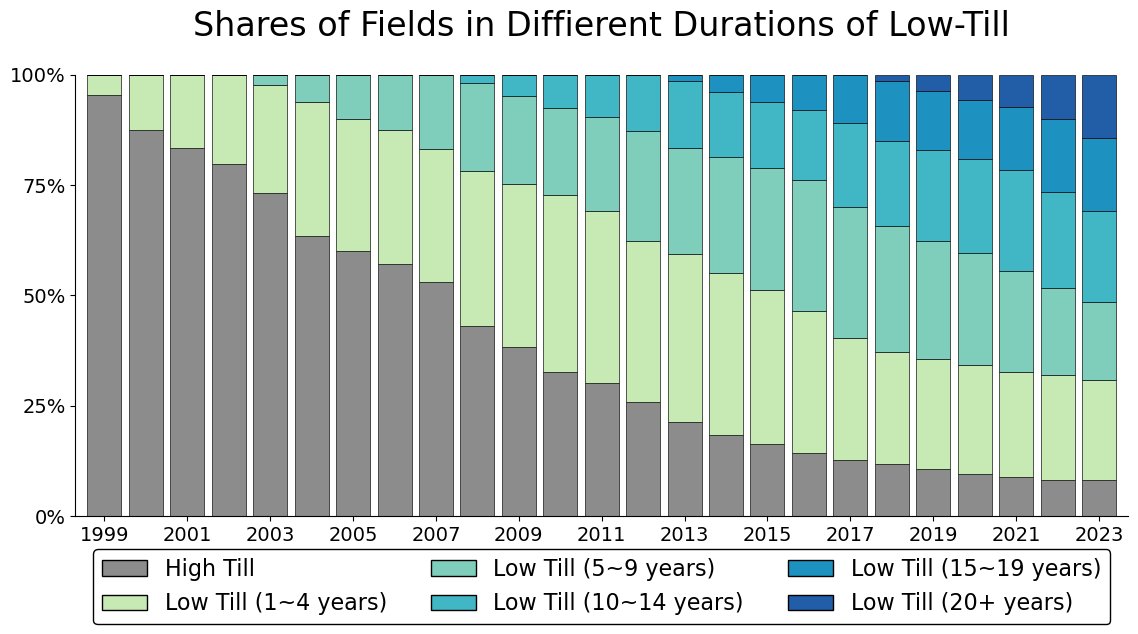

In [6]:
fig, ax = plt.subplots(figsize=(14, 6.5))

plot_stacked(
    ax,
    counts_never_conventional,
    never_conventional_order,
    "Shares of Fields in Diffierent Durations of Low-Till",
    "",
    as_share=True,
)

ax.set_title(
    "Shares of Fields in Diffierent Durations of Low-Till",
    x=0.5,
    y=1.05,
    pad=12,
    fontsize=24
)

fig.tight_layout(rect=(0, 0, 0.82, 1))
plt.show()